In [72]:
import pandas as pd

In [110]:
behaviors_path = "/Users/tricialee/Documents/MasterUU/Media/ASM/MINDsmall_train/behaviors.tsv"
news_path = "/Users/tricialee/Documents/MasterUU/Media/ASM/MINDsmall_train/news.tsv"
bbc_folder = "/Users/tricialee/Documents/MasterUU/Media/ASM/BBC"

# behaviors.tsv columns
behaviors_cols = ["impression_id", "user_id", "time", "history", "impressions"]

# news.tsv columns
news_cols = ["news_id", "category", "subcategory", "title", "abstract",
             "url", "title_entities", "abstract_entities"]

behaviors = pd.read_csv(
    behaviors_path,
    sep="\t",
    header=None,
    names=behaviors_cols
)

news = pd.read_csv(
    news_path,
    sep="\t",
    header=None,
    names=news_cols,
    usecols=[0, 1, 2, 3, 4, 5, 6, 7]
)

print(behaviors.iloc[0].to_string())
print(news.iloc[0].to_string())
print("\nBehaviors sample:")
print(behaviors.head())
print("\nNews sample:")
print(news.head())

impression_id                                                    1
user_id                                                     U13740
time                                         11/11/2019 9:05:58 AM
history          N55189 N42782 N34694 N45794 N18445 N63302 N104...
impressions                                      N55689-1 N35729-0
news_id                                                         N55528
category                                                     lifestyle
subcategory                                            lifestyleroyals
title                The Brands Queen Elizabeth, Prince Charles, an...
abstract             Shop the notebooks, jackets, and more that the...
url                      https://assets.msn.com/labs/mind/AAGH0ET.html
title_entities       [{"Label": "Prince Philip, Duke of Edinburgh",...
abstract_entities                                                   []

Behaviors sample:
   impression_id user_id                   time  \
0              1  U13740  1

In [111]:
behaviors_history = behaviors[["user_id", "history"]].dropna()

print("\nAfter dropping missing history:")
print(behaviors_history.head())



After dropping missing history:
  user_id                                            history
0  U13740  N55189 N42782 N34694 N45794 N18445 N63302 N104...
1  U91836  N31739 N6072 N63045 N23979 N35656 N43353 N8129...
2  U73700  N10732 N25792 N7563 N21087 N41087 N5445 N60384...
3  U34670  N45729 N2203 N871 N53880 N41375 N43142 N33013 ...
4   U8125                        N10078 N56514 N14904 N33740


In [75]:
behaviors_history["history_list"] = behaviors_history["history"].str.split(" ")

print("\nHistory list sample:")
print(behaviors_history[["user_id", "history", "history_list"]].head())


History list sample:
  user_id                                            history  \
0  U13740  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
1  U91836  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   
2  U73700  N10732 N25792 N7563 N21087 N41087 N5445 N60384...   
3  U34670  N45729 N2203 N871 N53880 N41375 N43142 N33013 ...   
4   U8125                        N10078 N56514 N14904 N33740   

                                        history_list  
0  [N55189, N42782, N34694, N45794, N18445, N6330...  
1  [N31739, N6072, N63045, N23979, N35656, N43353...  
2  [N10732, N25792, N7563, N21087, N41087, N5445,...  
3  [N45729, N2203, N871, N53880, N41375, N43142, ...  
4                   [N10078, N56514, N14904, N33740]  


In [76]:
user_news = behaviors_history[["user_id", "history_list"]].explode("history_list")

# rename column
user_news = user_news.rename(columns={"history_list": "news_id"})

print("\nUser-news exploded sample:")
print(user_news.head(10))



User-news exploded sample:
  user_id news_id
0  U13740  N55189
0  U13740  N42782
0  U13740  N34694
0  U13740  N45794
0  U13740  N18445
0  U13740  N63302
0  U13740  N10414
0  U13740  N19347
0  U13740  N31801
1  U91836  N31739


In [ ]:
news_category = news[["news_id", "category"]]

user_news_category = user_news.merge(news_category, on="news_id", how="left")

print("\nMerged user-news-category sample:")
print(user_news_category.head(10))


Merged user-news-category sample:
  user_id news_id   category
0  U13740  N55189         tv
1  U13740  N42782     sports
2  U13740  N34694         tv
3  U13740  N45794       news
4  U13740  N18445     sports
5  U13740  N63302  lifestyle
6  U13740  N10414     movies
7  U13740  N19347       news
8  U13740  N31801       news
9  U91836  N31739       news


In [78]:
user_category_count = (
    user_news_category
    .groupby(["user_id", "category"])
    .size()
    .reset_index(name="count")
)

print("\nUser-category count sample:")
print(user_category_count.head(10))


User-category count sample:
  user_id       category  count
0    U100      lifestyle      2
1    U100          music      1
2    U100           news      1
3    U100         sports      2
4    U100             tv      4
5   U1000  entertainment      3
6   U1000        finance      3
7   U1000      lifestyle      3
8  U10001   foodanddrink      2
9  U10001      lifestyle      2


In [79]:
user_total_count = (
    user_category_count
    .groupby("user_id")["count"]
    .sum()
    .reset_index(name="total_count")
)

print("\nUser total count sample:")
print(user_total_count.head())



User total count sample:
  user_id  total_count
0    U100           10
1   U1000            9
2  U10001           30
3  U10003           16
4  U10008           23


In [80]:
user_category_pattern = user_category_count.merge(user_total_count, on="user_id", how="left")

user_category_pattern["percentage"] = (
    user_category_pattern["count"] / user_category_pattern["total_count"]
)

user_category_pattern["percentage_pct"] = (
    user_category_pattern["percentage"] * 100
).round(2)

print("\nUser category pattern sample:")
print(user_category_pattern.head(20))



User category pattern sample:
   user_id       category  count  total_count  percentage  percentage_pct
0     U100      lifestyle      2           10    0.200000           20.00
1     U100          music      1           10    0.100000           10.00
2     U100           news      1           10    0.100000           10.00
3     U100         sports      2           10    0.200000           20.00
4     U100             tv      4           10    0.400000           40.00
5    U1000  entertainment      3            9    0.333333           33.33
6    U1000        finance      3            9    0.333333           33.33
7    U1000      lifestyle      3            9    0.333333           33.33
8   U10001   foodanddrink      2           30    0.066667            6.67
9   U10001      lifestyle      2           30    0.066667            6.67
10  U10001           news      6           30    0.200000           20.00
11  U10001         sports     18           30    0.600000           60.00
12  U10

In [81]:
category_total = user_category_pattern.groupby("category")["count"].sum()

print(category_total)

category
autos             178621
entertainment     165519
finance           391906
foodanddrink      273451
health            230010
kids                 161
lifestyle         529650
middleeast            69
movies            181275
music             131851
news             1603654
sports            728254
travel            164224
tv                366764
video             101820
weather            60410
Name: count, dtype: int64


In [82]:
user_category_pattern = user_category_pattern.sort_values(
    by=["user_id", "percentage"],
    ascending=[True, False]
)

print("\nSorted user category pattern sample:")
print(user_category_pattern.head(20))


Sorted user category pattern sample:
   user_id       category  count  total_count  percentage  percentage_pct
4     U100             tv      4           10    0.400000           40.00
0     U100      lifestyle      2           10    0.200000           20.00
3     U100         sports      2           10    0.200000           20.00
1     U100          music      1           10    0.100000           10.00
2     U100           news      1           10    0.100000           10.00
5    U1000  entertainment      3            9    0.333333           33.33
6    U1000        finance      3            9    0.333333           33.33
7    U1000      lifestyle      3            9    0.333333           33.33
11  U10001         sports     18           30    0.600000           60.00
10  U10001           news      6           30    0.200000           20.00
8   U10001   foodanddrink      2           30    0.066667            6.67
9   U10001      lifestyle      2           30    0.066667            6.67


In [83]:
category_map = {
    "autos": "science-and-nature",
    "entertainment": "entertainment",
    "finance": "documentaries",
    "foodanddrink": "lifestyle",
    "health": "lifestyle",
    "kids": "cbbc",
    "lifestyle": "lifestyle",
    "middleeast": "documentaries",
    "movies": "films",
    "music": "music",
    "news": "documentaries",
    "sports": "sports",
    "travel": "lifestyle",
    "tv": "entertainment",
    "video": "entertainment",
    "weather": "science-and-nature"
}

user_category_pattern["bbc_category"] = user_category_pattern["category"].map(category_map)
user_category_pattern[["category","bbc_category"]].drop_duplicates()
bbc_category_total = (
    user_category_pattern
    .groupby("bbc_category")["count"]
    .sum()
    .sort_values(ascending=False)
)

print(bbc_category_total)
bbc_dist = bbc_category_total / bbc_category_total.sum()

print(bbc_dist)



bbc_category
documentaries         1995629
lifestyle             1197335
sports                 728254
entertainment          634103
science-and-nature     239031
films                  181275
music                  131851
cbbc                      161
Name: count, dtype: int64
bbc_category
documentaries         0.390715
lifestyle             0.234420
sports                0.142581
entertainment         0.124148
science-and-nature    0.046799
films                 0.035491
music                 0.025814
cbbc                  0.000032
Name: count, dtype: float64


In [84]:
pd.set_option("display.max_columns", None)
print(user_category_pattern.head(10))

   user_id       category  count  total_count  percentage  percentage_pct  \
4     U100             tv      4           10    0.400000           40.00   
0     U100      lifestyle      2           10    0.200000           20.00   
3     U100         sports      2           10    0.200000           20.00   
1     U100          music      1           10    0.100000           10.00   
2     U100           news      1           10    0.100000           10.00   
5    U1000  entertainment      3            9    0.333333           33.33   
6    U1000        finance      3            9    0.333333           33.33   
7    U1000      lifestyle      3            9    0.333333           33.33   
11  U10001         sports     18           30    0.600000           60.00   
10  U10001           news      6           30    0.200000           20.00   

     bbc_category  
4   entertainment  
0       lifestyle  
3          sports  
1           music  
2   documentaries  
5   entertainment  
6   document

In [85]:
user_podcast_pattern = (
    user_category_pattern
    .groupby(["user_id", "bbc_category"])["count"]
    .sum()
    .reset_index()
)
user_podcast_pattern["total"] = (
    user_podcast_pattern
    .groupby("user_id")["count"]
    .transform("sum")
)
user_podcast_pattern["percentage"] = (
    user_podcast_pattern["count"] /
    user_podcast_pattern["total"]
)
print(user_podcast_pattern.head(20))


   user_id        bbc_category  count  total  percentage
0     U100       documentaries      1     10    0.100000
1     U100       entertainment      4     10    0.400000
2     U100           lifestyle      2     10    0.200000
3     U100               music      1     10    0.100000
4     U100              sports      2     10    0.200000
5    U1000       documentaries      3      9    0.333333
6    U1000       entertainment      3      9    0.333333
7    U1000           lifestyle      3      9    0.333333
8   U10001       documentaries      6     30    0.200000
9   U10001       entertainment      2     30    0.066667
10  U10001           lifestyle      4     30    0.133333
11  U10001              sports     18     30    0.600000
12  U10003       documentaries      8     16    0.500000
13  U10003           lifestyle      4     16    0.250000
14  U10003  science-and-nature      2     16    0.125000
15  U10003              sports      2     16    0.125000
16  U10008       documentaries 

In [86]:
#Compute KMEAN
user_genre_dist = (
    user_podcast_pattern
    .pivot(index="user_id", columns="bbc_category", values="percentage")
    .fillna(0)
)

from sklearn.cluster import KMeans

X = user_genre_dist.values

kmeans = KMeans(n_clusters=6,n_init=20,random_state=42)
kmeans.fit(X)

user_genre_dist["persona"] = kmeans.labels_

print(user_genre_dist.head())

bbc_category  cbbc  documentaries  entertainment  films  lifestyle  music  \
user_id                                                                     
U100           0.0       0.100000       0.400000    0.0   0.200000    0.1   
U1000          0.0       0.333333       0.333333    0.0   0.333333    0.0   
U10001         0.0       0.200000       0.066667    0.0   0.133333    0.0   
U10003         0.0       0.500000       0.000000    0.0   0.250000    0.0   
U10008         0.0       0.478261       0.217391    0.0   0.130435    0.0   

bbc_category  science-and-nature    sports  persona  
user_id                                              
U100                    0.000000  0.200000        5  
U1000                   0.000000  0.000000        5  
U10001                  0.000000  0.600000        1  
U10003                  0.125000  0.125000        3  
U10008                  0.130435  0.043478        3  


In [87]:
persona_profile = user_genre_dist.groupby("persona").mean()

print(persona_profile.head(8).to_string())
user_genre_dist["persona"].value_counts()

print(user_genre_dist)

bbc_category      cbbc  documentaries  entertainment     films  lifestyle     music  science-and-nature    sports
persona                                                                                                          
0             0.000000       0.222849       0.086124  0.033181   0.159225  0.023169            0.383654  0.091797
1             0.000000       0.216236       0.088847  0.034822   0.110510  0.022515            0.031050  0.496020
2             0.000006       0.173610       0.108017  0.035935   0.577983  0.025766            0.029367  0.049316
3             0.000002       0.438711       0.109688  0.043974   0.234522  0.029353            0.043716  0.100035
4             0.000005       0.747875       0.062099  0.018666   0.070258  0.011015            0.028991  0.061092
5             0.000000       0.189187       0.413457  0.074026   0.185476  0.050734            0.021275  0.065845
bbc_category  cbbc  documentaries  entertainment     films  lifestyle  \
user_id        

In [88]:
user_total = user_podcast_pattern.drop_duplicates("user_id").set_index("user_id")["total"]
user_genre_dist["total_views"] = user_genre_dist.index.map(user_total)
print(user_genre_dist)

bbc_category  cbbc  documentaries  entertainment     films  lifestyle  \
user_id                                                                 
U100           0.0       0.100000       0.400000  0.000000   0.200000   
U1000          0.0       0.333333       0.333333  0.000000   0.333333   
U10001         0.0       0.200000       0.066667  0.000000   0.133333   
U10003         0.0       0.500000       0.000000  0.000000   0.250000   
U10008         0.0       0.478261       0.217391  0.000000   0.130435   
...            ...            ...            ...       ...        ...   
U9993          0.0       0.500000       0.500000  0.000000   0.000000   
U9995          0.0       0.132353       0.044118  0.014706   0.764706   
U9996          0.0       0.000000       0.200000  0.000000   0.800000   
U9997          0.0       0.076923       0.076923  0.000000   0.846154   
U9999          0.0       0.714286       0.095238  0.000000   0.047619   

bbc_category     music  science-and-nature    spor

In [89]:
!pip install matplotlib
import matplotlib.pyplot as plt

In [90]:
print(user_genre_dist.groupby("persona")["total_views"].describe())

           count        mean         std  min   25%   50%     75%      max
persona                                                                   
0         2422.0   57.180429  183.315459  1.0   6.0  13.0   36.75   3610.0
1         7858.0   92.236065  308.440847  1.0   8.0  19.0   62.00  10416.0
2         8131.0   87.237978  256.198372  1.0   8.0  20.0   64.00   6290.0
3        14977.0  155.485211  473.407890  2.0  12.0  34.0  115.00  18972.0
4         8247.0   91.851219  351.006654  1.0   6.0  15.0   51.00   9504.0
5         7473.0   60.059682  166.287608  1.0   7.0  15.0   45.00   4520.0


In [91]:
# Remove outliers in total_views within each persona using IQR rule
def remove_outliers_by_persona(df):
    kept_parts = []

    for p, group in df.groupby("persona"):
        q1 = group["total_views"].quantile(0.25)
        q3 = group["total_views"].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        group_filtered = group[
            (group["total_views"] >= lower) &
            (group["total_views"] <= upper)
        ].copy()

        kept_parts.append(group_filtered)

    return pd.concat(kept_parts).sort_index()

# overwrite user_genre_dist
user_genre_dist = remove_outliers_by_persona(user_genre_dist)

print(user_genre_dist.shape)
print(user_genre_dist.groupby("persona")["total_views"].describe())

(42605, 10)
           count       mean        std  min   25%   50%    75%    max
persona                                                              
0         2088.0  17.409962  17.437452  1.0   6.0  10.0  23.25   82.0
1         6821.0  27.727166  30.519335  1.0   7.0  15.0  36.00  141.0
2         7075.0  28.866431  32.000682  1.0   7.0  15.0  38.00  148.0
3        13033.0  51.181232  58.414612  2.0  11.0  26.0  69.00  268.0
4         7067.0  21.943257  24.583696  1.0   6.0  12.0  28.00  118.0
5         6521.0  21.307928  22.258216  1.0   6.0  12.0  28.00  102.0


persona
0     2088
1     6821
2     7075
3    13033
4     7067
5     6521
Name: count, dtype: int64


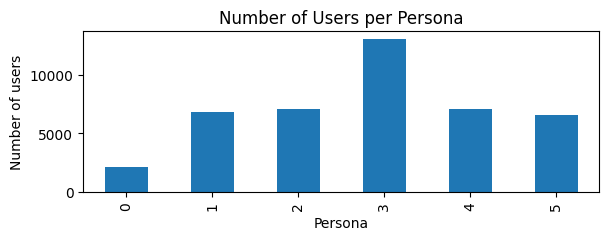

In [92]:
persona_counts = user_genre_dist["persona"].value_counts().sort_index()
print(persona_counts)
plt.figure(figsize=(6.19, 2.51))

persona_counts.plot(kind="bar")

plt.xlabel("Persona")
plt.ylabel("Number of users")
plt.title("Number of Users per Persona")

plt.tight_layout()
plt.show()

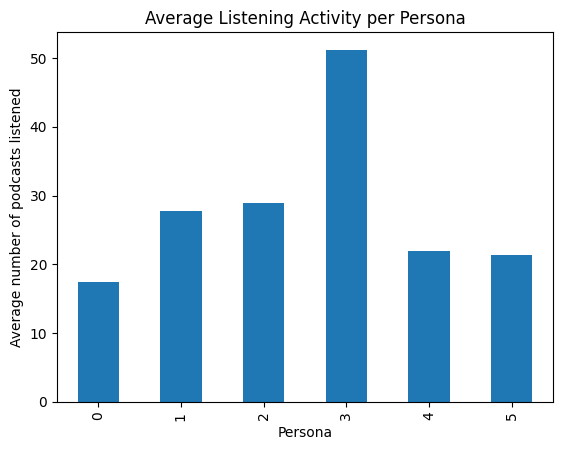

In [93]:
persona_activity = (
    user_genre_dist
    .groupby("persona")["total_views"]
    .mean()
)

persona_activity.plot(kind="bar")
plt.xlabel("Persona")
plt.ylabel("Average number of podcasts listened")
plt.title("Average Listening Activity per Persona")
plt.show()

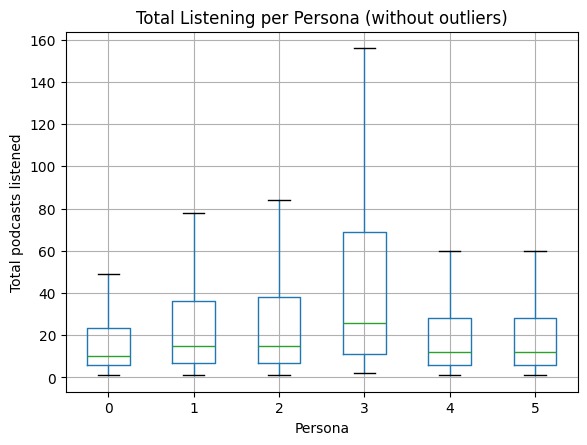

In [94]:
import matplotlib.pyplot as plt

user_genre_dist.boxplot(
    column="total_views",
    by="persona",
    showfliers=False
)

plt.title("Total Listening per Persona (without outliers)")
plt.suptitle("")
plt.xlabel("Persona")
plt.ylabel("Total podcasts listened")
plt.show()

In [95]:
#Syntatic Data implement
import os
import math
import random
import pickle
import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

bbc_data = {}

for file in os.listdir(bbc_folder):
    if file.endswith(".pkl"):
        genre_name = file.replace(".pkl", "")
        file_path = os.path.join(bbc_folder, file)
        
        with open(file_path, "rb") as f:
            obj = pickle.load(f)
        
        if isinstance(obj, pd.DataFrame):
            df = obj.copy()
        else:
            df = pd.DataFrame(obj)
        
        bbc_data[genre_name] = df

print("Loaded genres:", list(bbc_data.keys()))

Loaded genres: ['science-and-nature', 'music', 'sports', 'entertainment', 'lifestyle', 'cbbc', 'films', 'documentaries']


/var/folders/2w/126lfsqn7dq77wr9fbt2xkgc0000gn/T/ipykernel_85717/3672627126.py:20: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/var/folders/2w/126lfsqn7dq77wr9fbt2xkgc0000gn/T/ipykernel_85717/3672627126.py:20: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage o

In [96]:
for genre, df in bbc_data.items():
    df = df.copy()
    
    # force convert duration_sec to numeric
    df["duration_sec"] = pd.to_numeric(df["duration_sec"], errors="coerce")
    
    # drop invalid rows
    df = df.dropna(subset=["duration_sec"])
    df = df[df["duration_sec"] > 0].reset_index(drop=True)
    
    bbc_data[genre] = df

In [97]:
for genre, df in bbc_data.items():
    print(genre, df["duration_sec"].dtype)

science-and-nature int64
music int64
sports int64
entertainment int64
lifestyle int64
cbbc float64
films int64
documentaries int64


In [98]:
non_genre_cols = ["persona", "total_views"]
genre_cols = [c for c in user_genre_dist.columns if c not in non_genre_cols]

print("Genre columns in user_genre_dist:")
print(genre_cols)


non_genre_cols = ["persona", "total_views"]
genre_cols = [c for c in user_genre_dist.columns if c not in non_genre_cols]

print("Genre columns in user_genre_dist:")
print(genre_cols)

available_bbc_genres = set(bbc_data.keys())
usable_genres = [g for g in genre_cols if g in available_bbc_genres]

print("Usable genres:")
print(usable_genres)

Genre columns in user_genre_dist:
['cbbc', 'documentaries', 'entertainment', 'films', 'lifestyle', 'music', 'science-and-nature', 'sports']
Genre columns in user_genre_dist:
['cbbc', 'documentaries', 'entertainment', 'films', 'lifestyle', 'music', 'science-and-nature', 'sports']
Usable genres:
['cbbc', 'documentaries', 'entertainment', 'films', 'lifestyle', 'music', 'science-and-nature', 'sports']


In [99]:
import math
import numpy as np
import pandas as pd


# 1. Assign popularity group
def assign_popularity_group(df):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True).copy()

    n = len(df)
    if n == 0:
        return df

    head_cut = math.ceil(n * 0.10)
    mid_cut = math.ceil(n * 0.30)   # top 10% + next 20%

    groups = []
    for i in range(n):
        if i < head_cut:
            groups.append("head")
        elif i < mid_cut:
            groups.append("mid")
        else:
            groups.append("tail")

    df["popularity_group"] = groups
    df["popularity_rank"] = np.arange(1, n + 1)
    return df



# 2. Assign quality label
def assign_quality_label(df):
    df = df.copy()
    quality_labels = []

    for _, row in df.iterrows():
        group = row["popularity_group"]

        if group == "head":
            p_good = 0.60
        elif group == "mid":
            p_good = 0.45
        else:
            p_good = 0.30

        q = "good" if np.random.rand() < p_good else "bad"
        quality_labels.append(q)

    df["quality_label"] = quality_labels
    return df


# Apply popularity + quality to each genre table
for genre in usable_genres:
    bbc_data[genre] = assign_popularity_group(bbc_data[genre])

for genre in usable_genres:
    bbc_data[genre] = assign_quality_label(bbc_data[genre])



# 3. Listen ratio rule
def sample_listen_ratio(popularity_group, quality_label):
    if popularity_group in ["head", "mid"]:
        if quality_label == "good":
            return np.random.uniform(0.65, 0.98)
        else:
            return np.random.uniform(0.10, 0.60)
    else:  # tail
        if quality_label == "good":
            return np.random.uniform(0.65, 0.98)
        else:
            return np.random.uniform(0.03, 0.60)

# 4. Save rule
def generate_save(listen_ratio):
    if listen_ratio >= 0.75:
        p_save = 0.35
    elif listen_ratio >= 0.35:
        p_save = 0.12
    else:
        p_save = 0.01

    return "yes" if np.random.rand() < p_save else "no"

# 5. Popularity-biased item sampling
POP_GROUPS = ["head", "mid", "tail"]
POP_GROUP_PROBS = [0.50, 0.30, 0.20]

def sample_podcast_from_genre(genre, bbc_data):
    df = bbc_data[genre]

    chosen_group = np.random.choice(POP_GROUPS, p=POP_GROUP_PROBS)
    subset = df[df["popularity_group"] == chosen_group]

    if len(subset) == 0:
        subset = df

    sampled_row = subset.sample(1).iloc[0]
    return sampled_row

# 6. Deterministic genre allocation
def allocate_genre_counts(probs, total_views, genre_names):
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()

    expected = probs * total_views
    base = np.floor(expected).astype(int)

    remainder = total_views - base.sum()
    fractional = expected - base
    order = np.argsort(-fractional)

    for i in range(remainder):
        base[order[i]] += 1

    return dict(zip(genre_names, base))


# 7. Generate synthetic view history
genre_prob_df = user_genre_dist[usable_genres].copy()

row_sums = genre_prob_df.sum(axis=1)

valid_users = row_sums[row_sums > 0].index
genre_prob_df = genre_prob_df.loc[valid_users].copy()

genre_prob_df = genre_prob_df.div(genre_prob_df.sum(axis=1), axis=0)

user_genre_dist = user_genre_dist.loc[valid_users].copy()

rows = []

for user_id in user_genre_dist.index:
    persona = user_genre_dist.loc[user_id, "persona"]
    total_views = int(user_genre_dist.loc[user_id, "total_views"])

    # genre probabilities for this user
    probs = genre_prob_df.loc[user_id].values
    genres = genre_prob_df.columns.tolist()

    # deterministic allocation
    genre_alloc = allocate_genre_counts(probs, total_views, genres)

    # loop through each genre with fixed allocated count
    for chosen_genre, n_views in genre_alloc.items():
        if n_views == 0:
            continue

        for _ in range(n_views):
            # sample a podcast within that genre
            podcast = sample_podcast_from_genre(chosen_genre, bbc_data)

            title = podcast["title"]
            category = chosen_genre

            duration_sec = pd.to_numeric(podcast["duration_sec"], errors="coerce")
            if pd.isna(duration_sec) or duration_sec <= 0:
                continue

            popularity_group = podcast["popularity_group"]
            quality_label = podcast["quality_label"]

            # sample listen ratio
            listen_ratio = sample_listen_ratio(popularity_group, quality_label)

            # compute view time
            viewtime_sec = int(round(duration_sec * listen_ratio))
            viewtime_sec = max(viewtime_sec, 1)

            # save only
            save = generate_save(listen_ratio)

            # define item type
            if popularity_group in ["head", "mid"] and quality_label == "good":
                item_type = "popular_good"
            elif popularity_group in ["head", "mid"] and quality_label == "bad":
                item_type = "popular_bad"
            elif popularity_group == "tail" and quality_label == "good":
                item_type = "unpopular_good"
            else:
                item_type = "unpopular_bad"

            rows.append({
                "user_id": user_id,
                "persona": persona,
                "title": title,
                "category": category,
                "viewtime_sec": viewtime_sec,
                "save": save,
                "duration_sec": duration_sec,
                "listen_ratio": listen_ratio,
                "popularity_group": popularity_group,
                "quality_label": quality_label,
                "item_type": item_type
            })

synthetic_view_history = pd.DataFrame(rows)

In [100]:
print(synthetic_view_history.head(10).to_string())
print("\nShape:", synthetic_view_history.shape)

  user_id  persona                                                                              title       category  viewtime_sec save  duration_sec  listen_ratio popularity_group quality_label       item_type
0    U100        5                                                         Monitor - A Poet in London  documentaries           384   no         728.0      0.527124             tail           bad   unpopular_bad
1    U100        5  The Great British Sewing Bee - Series 4: 7. Puzzling Patterns and Pattern Cutting  entertainment          2483   no        3552.0      0.698933             tail          good  unpopular_good
2    U100        5                                        RuPaul's Drag Race UK - Series 3: Episode 3  entertainment          2234   no        4196.0      0.532402              mid           bad     popular_bad
3    U100        5                                     Only Connect - Series 17: 22. Golfers v Scrubs  entertainment          1437  yes        1739.0      0

In [101]:
synthetic_view_history_simple = synthetic_view_history[
    ["user_id", "persona", "category", "title", "viewtime_sec", "save"]
].copy()

print(synthetic_view_history_simple.head(20).to_string())

   user_id  persona       category                                                                              title  viewtime_sec save
0     U100        5  documentaries                                                         Monitor - A Poet in London           384   no
1     U100        5  entertainment  The Great British Sewing Bee - Series 4: 7. Puzzling Patterns and Pattern Cutting          2483   no
2     U100        5  entertainment                                        RuPaul's Drag Race UK - Series 3: Episode 3          2234   no
3     U100        5  entertainment                                     Only Connect - Series 17: 22. Golfers v Scrubs          1437  yes
4     U100        5  entertainment                                                  MasterChef - Series 13: Episode 6           283   no
5     U100        5      lifestyle  Can't Get You Out of My Head - Series 1: 1. Part One - Bloodshed on Wolf Mountain          4003   no
6     U100        5      lifestyle       

In [102]:
synthetic_view_history.to_csv("synthetic_view_history_full.csv", index=False)
synthetic_view_history_simple.to_csv("synthetic_view_history_simple.csv", index=False)

In [103]:
user_genre_dist[usable_genres].mean().sort_values(ascending=False)

bbc_category
documentaries         0.360744
lifestyle             0.232671
entertainment         0.144113
sports                0.143057
science-and-nature    0.050120
films                 0.041620
music                 0.027674
cbbc                  0.000001
dtype: float64

In [104]:
for genre, df in bbc_data.items():
    print(genre, len(df))

science-and-nature 737
music 483
sports 337
entertainment 2051
lifestyle 320
cbbc 3970
films 165
documentaries 2779


In [105]:
synthetic_view_history["category"].value_counts(normalize=True)

category
documentaries         0.372578
lifestyle             0.240416
sports                0.139234
entertainment         0.133920
science-and-nature    0.047684
films                 0.039144
music                 0.027021
cbbc                  0.000002
Name: proportion, dtype: float64

In [106]:
exp_pop = (
    synthetic_view_history
    .groupby(["category", "popularity_group"])
    .size()
    .reset_index(name="views")
)

exp_pop["share_within_genre"] = (
    exp_pop["views"] /
    exp_pop.groupby("category")["views"].transform("sum")
)

print(exp_pop)

              category popularity_group   views  share_within_genre
0                 cbbc             head       2            0.666667
1                 cbbc              mid       1            0.333333
2        documentaries             head  259629            0.501048
3        documentaries              mid  155331            0.299767
4        documentaries             tail  103212            0.199185
5        entertainment             head   93527            0.502150
6        entertainment              mid   55551            0.298256
7        entertainment             tail   37175            0.199594
8                films             head   27400            0.503297
9                films              mid   16256            0.298598
10               films             tail   10785            0.198104
11           lifestyle             head  167032            0.499550
12           lifestyle              mid  100478            0.300504
13           lifestyle             tail   66855 

In [107]:
synthetic_view_history.groupby("item_type")["listen_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
item_type,,,,,,,,
popular_bad,485680.0,0.349917,0.144459,0.100001,0.224821,0.349674,0.475052,0.600000
popular_good,627438.0,0.815023,0.095189,0.650001,0.732536,0.815158,0.897370,0.980000
unpopular_bad,197186.0,0.314507,0.164413,0.030000,0.171969,0.314958,0.456723,0.599999
unpopular_good,80472.0,0.815452,0.095539,0.650006,0.732847,0.815277,0.898511,0.979996


In [108]:
exp_type = (
    synthetic_view_history
    .groupby(["category", "item_type"])
    .size()
    .reset_index(name="views")
)

exp_type["share_within_genre"] = (
    exp_type["views"] /
    exp_type.groupby("category")["views"].transform("sum")
)

print(exp_type)

              category       item_type   views  share_within_genre
0                 cbbc     popular_bad       1            0.333333
1                 cbbc    popular_good       2            0.666667
2        documentaries     popular_bad  185361            0.357721
3        documentaries    popular_good  229599            0.443094
4        documentaries   unpopular_bad   72226            0.139386
5        documentaries  unpopular_good   30986            0.059799
6        entertainment     popular_bad   65091            0.349476
7        entertainment    popular_good   83987            0.450930
8        entertainment   unpopular_bad   25343            0.136068
9        entertainment  unpopular_good   11832            0.063526
10               films     popular_bad   20694            0.380118
11               films    popular_good   22962            0.421778
12               films   unpopular_bad    7993            0.146819
13               films  unpopular_good    2792            0.05

bbc_category      cbbc  documentaries  entertainment     films  lifestyle  \
persona                                                                     
0             0.000000       0.216578       0.085611  0.033448   0.156174   
1             0.000000       0.209858       0.087405  0.034952   0.107660   
2             0.000006       0.167928       0.104912  0.035874   0.587606   
3             0.000000       0.440430       0.109206  0.045216   0.234860   
4             0.000000       0.754855       0.061511  0.018850   0.066887   
5             0.000000       0.187556       0.423979  0.074936   0.178129   

bbc_category     music  science-and-nature    sports  
persona                                               
0             0.023440            0.395806  0.088943  
1             0.022351            0.030371  0.507402  
2             0.025590            0.029286  0.048798  
3             0.030006            0.042852  0.097430  
4             0.011136            0.028106  0.058655 

<Figure size 619x400 with 0 Axes>

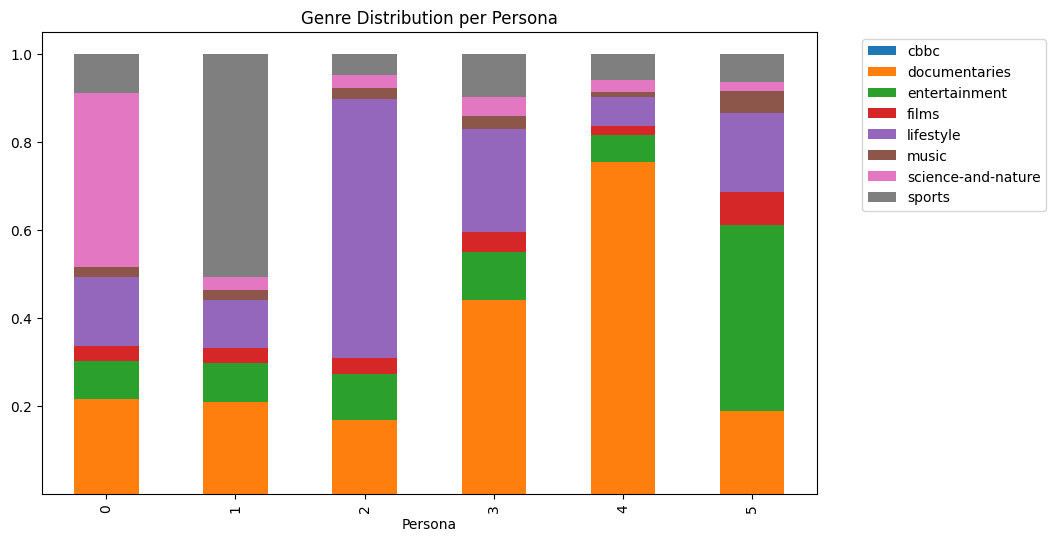

In [109]:
non_genre_cols = ["persona", "total_views"]
genre_cols = [c for c in user_genre_dist.columns if c not in non_genre_cols]
plt.figure(figsize=(6.19, 4))

persona_genre_dist = (
    user_genre_dist
    .groupby("persona")[genre_cols]
    .mean()
)

print(persona_genre_dist)

persona_genre_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Persona")
plt.title("Genre Distribution per Persona")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()